In [1]:
%load_ext autoreload
%autoreload 2
%config IPCompleter.greedy = True
import numpy as np
import pylab as plt
import pickle
import sys
import os

try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.path.abspath(os.getcwd())
externals_path = os.path.abspath(os.path.join(current_dir, '..', 'vendor'))
if externals_path not in sys.path:
    sys.path.insert(0, externals_path)
import pyEPR as epr

from EPR_master import EPR_master, get_modes_list

### General Workflow

In [2]:
pinfo = epr.ProjectInfo(project_path = 'D:\Candace\Victoria_hfss', project_name = 'Victoria_202605_2cooldown_final',
                        design_name = 'Victoria_MR_MEAL_1_4yale13_sideleo_Rubidium_Malaysia_wsiderr', setup_name='Setup1')
pinfo.junctions["JJ_C_MEAL"] = {
    "Lj_variable": "Lj_eff_MEAL",
    "rect": "JJ_C_MEAL",
    "line": "line_jj_MEAL",
    "length": "1.9um",
}

pinfo.junctions["JJ_C_MR"] = {
    "Lj_variable": "Lj_eff_MR",
    "rect": "JJ_C_MR",
    "line": "line_jj_MR",
    "length": "1.9um",
}

pinfo.junctions["LEO"] = {
    "Lj_variable": "Lj_qL",
    "rect": "JJ_qL",
    "line": "line_jj_L",
    "length": "1.9um",
}
pinfo.junctions["Malaysia"] = {
    "Lj_variable": "Lj_qM",
    "rect": "JJ_qM",
    "line": "line_jj_M",
    "length": "1.9um",
}
pinfo.junctions["Rubidium"] = {
    "Lj_variable": "Lj_qR",
    "rect": "JJ_qR",
    "line": "line_jj_R",
    "length": "1.9um",
}


pinfo.validate_junction_info()

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\qcrew\AppData\Local\Temp\ipykernel_17128\39101159.py:1: SyntaxWarning: invalid escape sequence '\C'
  pinfo = epr.ProjectInfo(project_path = 'D:\Candace\Victoria_hfss', project_name = 'Victoria_202605_2cooldown_final',
INFO 03:05PM [connect_project]: Connecting to Ansys Desktop API...
INFO 03:05PM [load_ansys_project]: 	File path to HFSS project found.
INFO 03:05PM [load_ansys_project]: 	Opened Ansys App
INFO 03:05PM [load_ansys_project]: 	Opened Ansys Desktop v2025.2.0
INFO 03:05PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    D:/Candace/Victoria_hfss/
	Project:   Victoria_202605_2cooldown_final
INFO 03:05PM [connect_design]: 	Opened active design
	Design:    Victoria_MR_MEAL_1_4yale13_sideleo_Rubidium_Malaysia_wsiderr [Solution type: Eigenmode]
INFO 03:05PM [get_setup]: 	Opened setup `Setup1`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 03:05PM [connect]: 	Connected to 

#### Analysis

In [3]:
pinfo.setup.analyze() # ANALYSIS

INFO 09:43AM [analyze]: Analyzing setup Big_setup


#### Optimetrics

In [33]:
optimetrics_index = 1
pinfo.design.optimetrics.get_setup_names()[optimetrics_index]

'Extensions_len'

In [34]:
pinfo.design.optimetrics.solve_setup(pinfo.design.optimetrics.get_setup_names()[optimetrics_index])

com_error: (-2147352567, 'Exception occurred.', (0, None, None, None, 0, -2147024341), None)

#### Core Analysis

In [3]:
_full_modes_dict = {"c_Malaysia":0,
    "r_MR":1,
    "r_MEAL":2,
    
    "qub_Malaysia":3,
    
    "q_Rubidium":4,
    "snail_meal": 5,
    "snail_mr": 6,

    "q_Leo":7,
    "c_Leo":8,
    
    "c_Rubidium":9,
    
    # "c_Rubidium": 10,
    "c_Malaysia2": 10, 
    
    "r_MR_": 11,
    "r_Malaysia": 12, 
    "r_Rubidium": 13, 
    
    "r_Leo": 14, }
# _full_modes_dict = {"Cavity": 0,
#           "Qubit": 1,
#           "Purcell": 2}
_to_analyse = {"c_Malaysia", "r_MR", "r_MEAL", "qub_Malaysia"}
modes_to_analyse = get_modes_list(_full_modes_dict, _to_analyse)
modes_indices = list(modes_to_analyse.values())
modes_indices

[0, 1, 2, 3]

In [4]:
eprd = epr.DistributedAnalysis(pinfo) # epr hfss analysis instance
eprd.do_EPR_analysis(variations=None, modes=modes_indices, append_analysis=True) # if new variations were added, comment the line above and run this. append_analysis=True will prevent previously analyzed variations from being reanalyzed.

ERROR 03:05PM [setup_data]: WARNING!   DESIGN FILENAME MAY BE TOO LONG! 


Design "Victoria_MR_MEAL_1_4yale13_sideleo_Rubidium_Malaysia_wsiderr" info:
	# eigenmodes    15
	# variations    4

Variation 0  [1/4]

  Mode 0 at 3.05 GHz   [1/15]
    Calculating ℰ_magnetic,ℰ_electric
       (ℰ_E-ℰ_H)/ℰ_E       ℰ_E       ℰ_H
                0.1%  1.728e-22 1.727e-22

    Calculating junction energy participation ration (EPR)
	method=`line_voltage`. First estimates:
	junction        EPR p_0j   sign s_0j    (p_capacitive)
		Energy fraction (Lj over Lj&Cj)= 99.63%
	JJ_C_MEAL       0.000110621  (+)        4.05631e-07
		Energy fraction (Lj over Lj&Cj)= 99.63%
	JJ_C_MR         0.000127613  (+)        4.6794e-07
		Energy fraction (Lj over Lj&Cj)= 99.49%
	LEO             4.47075e-10  (+)        2.29511e-12
		Energy fraction (Lj over Lj&Cj)= 98.88%
	Malaysia        0.000307588  (+)        3.47388e-06
		Energy fraction (Lj over Lj&Cj)= 99.34%
	Rubidium        7.39451e-10  (+)        4.88064e-12
		(U_tot_cap-U_tot_ind)/mean=-0.00%

  Mode 1 at 3.86 GHz   [2/15]
    Calculating

(WindowsPath('C:/data-pyEPR/Victoria_202605_2cooldown_final/Victoria_MR_MEAL_1_4yale13_sideleo_Rubidium_Malaysia_wsiderr/2026-05-05 15-05-59.npz'),
 ['0', '1', '2', '3'])

In [5]:
epra = epr.QuantumAnalysis(eprd.data_filename)

	 Differences in variations:


variation,0,1,2,3
_Lj_eff_MEAL,5nH,5nH,9nH,9nH
_Lj_eff_MR,5nH,9nH,5nH,9nH


### EPR Master

#### Initialization

Class needs to be aware of modes corresponding to qubits. There are multiple options to provide it. In the order of priority (e.g. if 1) and 2) are given, 1) will be used):

1) You can provide the indices of qubit modes as numpy.array() to qubits_indices argument.

2) You can specify the names of the modes and provide them via 'modes_names' argument. The class will automatically interpret modes which contain 'Qubit' or 'qub' in their names as qubits. Names of non-qubit modes are just for reference.

3) You can provide the information on the number of different modes in your setup via arguments num_of_qubs, num_of_cavs, num_of_rrs. The modes will then be recognised automatically.

If nothing was provided, option 3) is used with default values num_of_qubs=1, num_of_cavs=1, num_of_rrs=1.

For automatic mode recognition the following algorithm is used:

num_of_qubs modes with highest anharmonicities are interpreted to be qubits. Out of other modes, num_of_cavs modes are interpreted to be cavities. Then, num_of_rrs modes with the lowest frequencies that were not assigned yet are interpreted as RRs. Other modes' (if any) names are 'Mode {number of mode}'. Therefore, num_of_qubs + num_of_cavs + num_of_rrs can be less than the number of modes but can not be greater.

You can run the functions below in arbitrary order.

In [13]:
# modes_names = np.array(['Qubit', 'Cavity', 'Spurious high', 'RR'])
# modes_indices = [0, 1, 2, 3]
# modes_names = None
modes_names = np.array(list(modes_to_analyse.keys()))
Master = EPR_master(epra=epra, modes_indices=modes_indices, modes_names=modes_names, qubits_indices=None, num_of_qubs=1, num_of_cavs=1, num_of_rrs=1)

#### Print results for one variation

In [14]:
Master.print_fancy_results(variation_ind='0')

0, Starting the diagonalization
Finished the diagonalization


c:\Users\qcrew\anaconda3\envs\EPR_master-main\src\EPR_master.py:104: UserWarning: No lossy elements were introduced! Q-factors, T_1s and kappa/2pi will not be calculated
  warnings.warn("No lossy elements were introduced! Q-factors, T_1s and kappa/2pi will not be calculated")
c:\Users\qcrew\anaconda3\envs\EPR_master-main\EPR_master_env\Lib\site-packages\pandas\core\internals\managers.py:1923: ComplexWarning: Casting complex values to real discards the imaginary part
  result[rl.indexer] = arr


,HFSS,Dressed,Numerical
c_Malaysia,3.047669,3.047627,3.047614+0.000000j
r_MR,3.861765,3.861764,3.861766+0.000000j
r_MEAL,3.904537,3.904536,3.904537+0.000000j
qub_Malaysia,3.955945,3.785089,3.777237+0.000000j


,"g, MHz"
qub_Malaysia - c_Malaysia,20.721328
qub_Malaysia - r_MR,13.180191
qub_Malaysia - r_MEAL,0.761143


,c_Malaysia,r_MR,r_MEAL,qub_Malaysia
c_Malaysia,0.000011,0.000000,0.000002,0.084088
r_MR,0.000000,0.000000,0.000000,0.001190
r_MEAL,0.000002,0.000000,0.000002,0.000069
qub_Malaysia,0.084088,0.001190,0.000069,170.812883


c:\Users\qcrew\anaconda3\envs\EPR_master-main\EPR_master_env\Lib\site-packages\pandas\core\internals\managers.py:1856: ComplexWarning: Casting complex values to real discards the imaginary part
  arr = np.array(blk.values, dtype=dtype, copy=copy)


,c_Malaysia,r_MR,r_MEAL,qub_Malaysia
c_Malaysia,0.000033+0.000000j,0.000001+0.000000j,0.000002+0.000000j,0.196209+0.000000j
r_MR,0.000001+0.000000j,0.000000+0.000000j,0.000000+0.000000j,0.000489+0.000000j
r_MEAL,0.000002+0.000000j,0.000000+0.000000j,0.000002+0.000000j,0.000004+0.000000j
qub_Malaysia,0.196209+0.000000j,0.000489+0.000000j,0.000004+0.000000j,187.349088+0.000000j


#### Print variations sweep

Works if you have several variations to compare.

automatic_mode_recognition (bool, optional): whether to use modes set by user or define them automatically for each variation. Defaults to True.

In [15]:
Master.print_variations(automatic_mode_recognition=True)

1, Starting the diagonalization
Finished the diagonalization
2, Starting the diagonalization
Finished the diagonalization
3, Starting the diagonalization
Finished the diagonalization


c:\Users\qcrew\anaconda3\envs\EPR_master-main\EPR_master_env\Lib\site-packages\pandas\core\base.py:689: ComplexWarning: Casting complex values to real discards the imaginary part
  result = np.asarray(values, dtype=dtype)


,"Lj_eff_MEAL: 5nH, Lj_eff_MR: 5nH","Lj_eff_MEAL: 5nH, Lj_eff_MR: 9nH","Lj_eff_MEAL: 9nH, Lj_eff_MR: 5nH","Lj_eff_MEAL: 9nH, Lj_eff_MR: 9nH"
g qub_Malaysia - c_Malaysia MHz,20.721328+0.000000j,21.111047+0.000000j,34.335783+0.000000j,35.248389+0.000000j
g qub_Malaysia - r_MR MHz,13.180191+0.000000j,12.668383+0.000000j,12.525253+0.000000j,12.489370+0.000000j
g qub_Malaysia - r_MEAL MHz,0.761143+0.000000j,0.776759+0.000000j,0.792620+0.000000j,0.945581+0.000000j
"Freq, qub_Malaysia, GHz",3.777237+0.000000j,3.780283+0.000000j,3.779386+0.000000j,3.785993+0.000000j
"Freq, c_Malaysia, GHz",3.047614+0.000000j,3.047434+0.000000j,3.046948+0.000000j,3.046796+0.000000j
"Freq, r_MR, GHz",3.861766+0.000000j,3.860422+0.000000j,3.861552+0.000000j,3.859358+0.000000j
"Freq, r_MEAL, GHz",3.904537+0.000000j,3.907385+0.000000j,3.906988+0.000000j,3.906069+0.000000j
"Anharm, qub_Malaysia, MHz",187.349088+0.000000j,187.625336+0.000000j,187.557810+0.000000j,188.276142+0.000000j
"CHI qub_Malaysia-c_Malaysia, MHz",0.196209+0.000000j,0.194769+0.000000j,0.194660+0.000000j,0.190707+0.000000j
"CHI qub_Malaysia-r_MR, MHz",0.000489+0.000000j,0.000453+0.000000j,0.000508+0.000000j,0.000508+0.000000j


In [ ]:
purcell_length = 0.135 + np.pi * 0.275 * 3.5 + 0.4 * 3 + (2.24 - 2.065) * np.pi /2 + 3.2
print("Length of the Purcell filter is {:.4f} mm".format(purcell_length))
new_length = purcell_length * 7.565 / 8.65
print("The new length is {:.4f} mm".format(new_length))
shorten_length = 1.25
new_shorten_length = shorten_length + new_length - purcell_length
print("New value of the shorten lenght variable must be {:.4f} mm".format(new_shorten_length))

Length of the Purcell filter is 8.0537 mm
The new length is 7.0435 mm
New value of the shorten lenght variable must be 0.2398 mm


In [43]:
new_line_len = 8.51
old_line_len = new_line_len - new_shorten_length + shorten_length
8.22 * new_line_len / old_line_len

7.347765407912992

#### Calculate g

In [23]:
cav_freq = 6.261326e9
transmon_freq = 6.095531e9
chi = 1.170310e6
anharm = 296e6
delta = cav_freq - transmon_freq
g = np.sqrt(chi * delta)
# g = np.sqrt(chi * delta * (1 - delta / anharm))
print("Coupling g is {:.3f} MHz".format(g/1000_000))

Coupling g is 13.930 MHz


In [9]:
cav_freq = 6.258e9
transmon_freqs = np.array([6.580477, 6.118793, 6.070546, 5.925391, 5.863294, 5.803649])*1e9
anharmonicities = np.array([356.972451, 297.816825, 293.369275, 279.932154, 273.915646, 268.096762])*1e6
chis = np.array([-8.408180, 1.386982, 0.850733, 0.386182, 0.329574, 0.271189])*1e6
deltas = transmon_freqs - cav_freq

In [10]:
print("MORE PRECISE CALCULATION")
g2 = -chis * deltas * (1 + deltas / anharmonicities)
# print("g squared:\n", g2)
print("g [MHz]: \n", np.sqrt(abs(g2))/1e6)

MORE PRECISE CALCULATION
g [MHz]: 
 [71.83921831 10.14043015  7.58780185  4.91639197  7.57392574  9.25207354]


In [11]:
print("SIMPLE CALCULATION")
g2 = -chis * deltas
# print("g squared:\n", g2)
print("g [MHz]: \n", np.sqrt(abs(g2))/1e6)

SIMPLE CALCULATION
g [MHz]: 
 [52.07153408 13.89523671 12.62827398 11.33347294 11.40547392 11.10022492]


In [12]:
g_ = np.sqrt(abs(g2))/1e6

#### Plot the results

You can plot the results of pyEPR analysis against variation values. 

To do that, use Master.plot_res(value: str, saveas: str = None) function. 'value' options are the names of the rows in EPR_master.print_variations() function, just copy them. If you want to save the plot, specify the filename at the saveas argument without file extension (it is hardcoded to be .jpg)

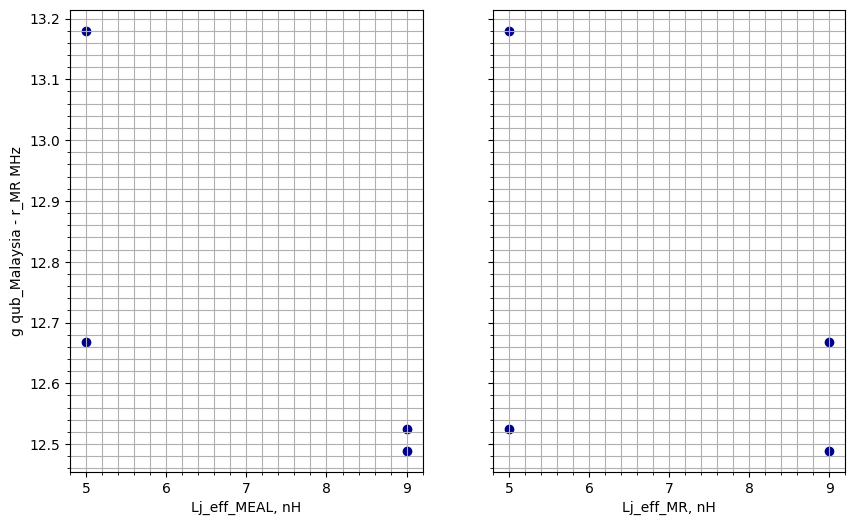

In [16]:
saveas_filename = None
# saveas_filename = 'g_qubit_cav'
Master.plot_res(value='g qub_Malaysia - r_MR MHz', saveas=saveas_filename, scale='linear')
# ax = plt.gca()
# ax.set(ylim=[-0.05, 0.55])
# ax.set(yscale='log')
# fig = plt.gcf()
# fig.savefig('DOUBLE CHI Qubit-Mode 1, MHz.jpg', bbox_inches='tight', dpi=600)

#### Plot the correlation

You can also plot the correlation between two values. Copy 'value_x' and 'value_y' from EPR_master.print_variations() functions. If you want to save the plot, specify the filename at the saveas argument without file extension (it is hardcoded to be .jpg) 

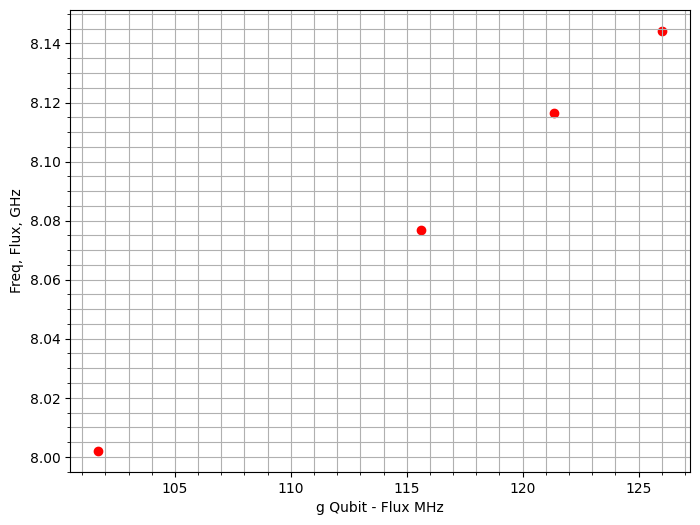

In [25]:
# correlation_filename = None
correlation_filename = 'delta_test_g and g qubit flux correlation'
Master.plot_correlation(value_x='g Qubit - Flux MHz', value_y='Freq, Flux, GHz', saveas=correlation_filename)
# ax = plt.gca()
# ax.set(ylim=[0, 0.83], xlim=[4.4, 7.5])
# fig = plt.gcf()
# fig.savefig('Weird chi cav.jpg', bbox_inches='tight', dpi=600)

In [5]:
pinfo.disconnect()

### Save to Pickle

#### Save

In [37]:
with open('with_copper.pickle', 'wb') as handle:
    pickle.dump(Master, handle, protocol=pickle.HIGHEST_PROTOCOL)

#### Load

In [38]:
with open('with_copper.pickle', 'rb') as handle:
    Master = pickle.load(handle)

### Snake Length

In [24]:
res_repeatimes_c = 2
res_length_c = 0.7
res_diameter_c = 0.77
res_uplead_length_c = 0.77
res_downlead_length_c = 1.8
res_uppad_diameter_c = 0.5
res_downpad_diameter_c = 0.15
L = res_repeatimes_c * (2 * res_length_c + np.pi * res_diameter_c) + 0.5 * np.pi * res_diameter_c + res_uplead_length_c + res_downlead_length_c + 0.5*res_uppad_diameter_c + 0.5 * res_downpad_diameter_c
print("Snake RR length is {:.2f} mm".format(L))

Snake RR length is 11.74 mm


### Q-factors

In [9]:
heights = np.array([0.25, 0.35, 0.4, 0.45, 0.54, 0.55, 0.65, 0.75])
heights_ = np.array([0.42])
Qs = np.array([7.70441e8, 1.92240e9, 8.22949e9, 4.83009e9, 2.25392e8, 1.90751e8, 6.42864e6, 3.36856e6])
Qs_ = np.array([2.00019e12])
Q__ = np.array([9.74817e8, 1.80232e9])
heights__ = np.array([0.3, 0.4, 0.5])

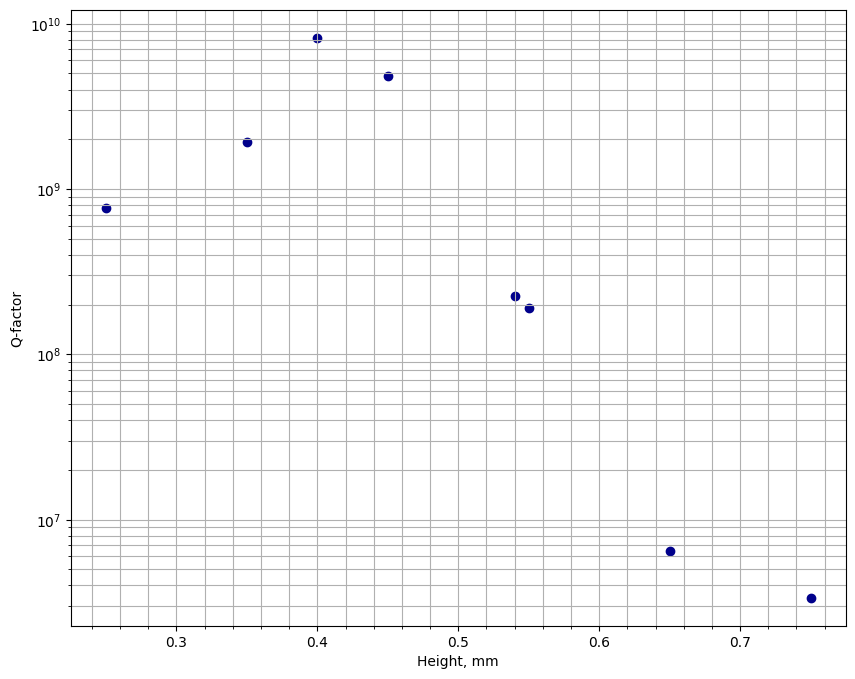

In [12]:
fig = plt.figure(figsize=(10, 8))
ax = plt.gca()
ax.scatter(heights, Qs, color='darkblue')
ax.set(xlabel="Height, mm", ylabel="Q-factor", yscale='log')
ax.minorticks_on()
ax.grid(which='both')